# Key Independent Variables

In [02_correlation.ipynb](02_correlation.ipynb) we found key 5 variables.
In this notebook, see more detail on the key independent variables and their correlation with the dependent variable.

First, we prepare understandable labels for key independent variables.

In [9]:
variables = {
    'DP02_0065PE': "Bachelor's Degree",
    'DP03_0097PE': "Private Health Insurance",
    'DP02_0076PE': "Disability",
    'DP03_0004PE': "Employment",
    'DP03_0128PE': "Poverty",
}

In [10]:
# data loading code is in load_data.py
from load_data import load_places, load_acs_profiles
# get the places data
df_places = load_places()
# get the ACS profiles data (This takes a while to load because it loads multiple files and merges them)
df_acs_profiles = load_acs_profiles()

In [11]:
df_places = df_places[['StateAbbr', 'StateDesc', 'CountyName', 'CountyFIPS', 'MHLTH_AdjPrev']]

In [12]:
df_acs_profiles = df_acs_profiles[['CountyFIPS'] + list(variables.keys())]

## Distribution

C:\Users\user\AppData\Roaming\Python\Python312\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.5.2)
  from scipy.stats import gaussian_kde


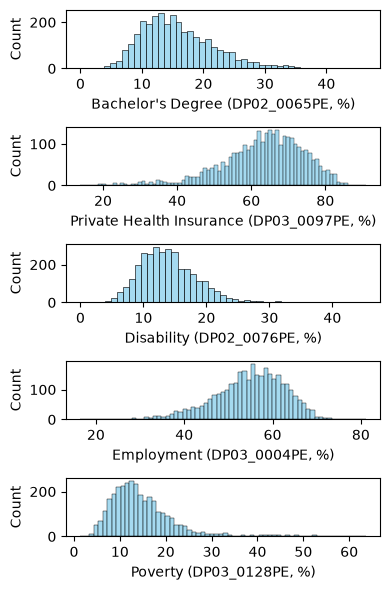

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt


fig, axes = plt.subplots(len(variables), 1, figsize=(4, 6), sharex=False)

import math


for ax, var in zip(axes, variables):
    bins = math.ceil(df_acs_profiles[var].max()) - math.floor(df_acs_profiles[var].min()) + 1
    sns.histplot(df_acs_profiles[var], bins=bins, ax=ax, color='skyblue')
    # ax.set_title(f"Distribution of {name_map[var]} ({var})")
    ax.set_xlabel(f"{variables[var]} ({var}, %)")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()


## Interaction

See the interaction between the key independent variables.

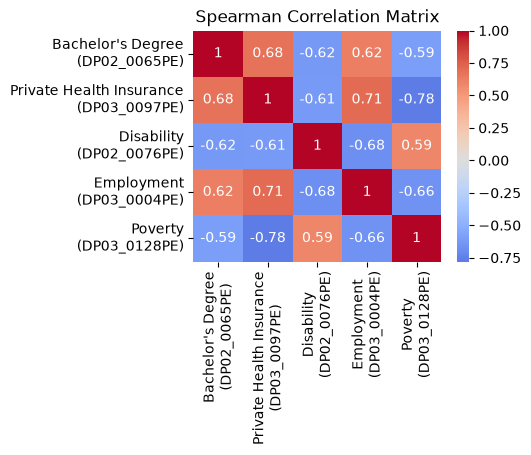

In [16]:
corr_matrix = df_acs_profiles[variables.keys()].corr(method='spearman')

labels = {var: variables.get(var, var) + f"\n({var})" for var in variables.keys()}
corr_matrix.rename(columns=labels, index=labels, inplace=True)

# plot the correlation matrix
plt.figure(figsize=(4, 3))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Spearman Correlation Matrix')
plt.xlabel("")
plt.ylabel("")
plt.show()

## 2D Distribution

Draw and see 2D distribution of the key independent variables and the dependent variable.

In [17]:
import pandas as pd
df_merged = pd.merge(df_places, df_acs_profiles, on='CountyFIPS', how='inner')

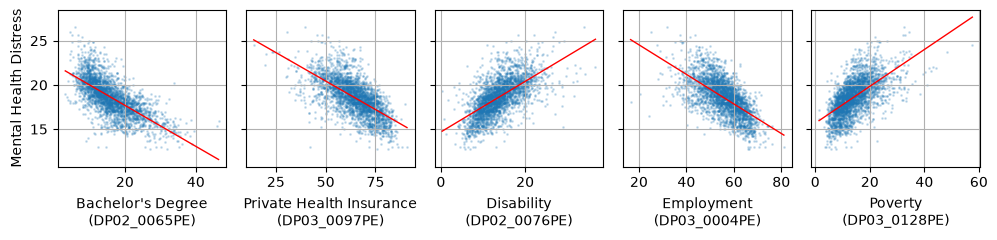

In [ ]:
import numpy as np

fig, axes = plt.subplots(
    1, 5,
    figsize=(10, 2.5),
    sharey=True
)

for i, var in enumerate(variables):
    ax = axes[i]
    df = df_merged[[var, 'MHLTH_AdjPrev']].dropna()
    ax.scatter(df[var], df['MHLTH_AdjPrev'], alpha=0.2, s=1)
    ax.set_xlabel(variables[var] + '\n(' + var + ')')
    if i == 0:
        ax.set_ylabel('Mental Health Distress')

    # OLS
    # The data contains a few thousand records,
    # so OLS is not so different from RLM.
    m, b = np.polyfit(df[var], df['MHLTH_AdjPrev'], 1)
    x_line = np.linspace(df[var].min(), df[var].max(), 100)
    ax.plot(x_line, m * x_line + b, color='red', linewidth=1)
    ax.grid(True)

    if i > 0:
        ax.tick_params(axis='y', labelleft=False)

plt.tight_layout()
plt.show()
